In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import numpy as np

import matplotlib.pyplot as plt
import plotly.graph_objects as go
import seaborn as sns
from mad.configs import titan1_stages, titan2_stages, minuteman_stages
from mad.configs import B53_warhead
from mad.configs import EARTH_SETTINGS
from mad.objs import Planet, PlanetConfig
from mad.objs import RocketConfig, RocketStage, RocketStageConfig, Rocket, RVConfig
from mad.guidances import TabulatedBallistic, NoGuidance
from mad.simulation import Simulation
from mad.utils.logger import SourceLogger
from mad.utils.plotters import plot_2D_planet_with_points

logger = SourceLogger()

In [30]:
EARTH_SETTINGS["position"] = [0.0, 0.0]

launchsite_target_distance_km = 1_000
earth = Planet(PlanetConfig(**EARTH_SETTINGS))
launchpad = earth.random_point_at_surface(name="Launchpad", altitude=10, dims=2)
target = earth.point_at_distance(launchpad, distance_km=launchsite_target_distance_km, name="Target", dims=2)

earth

Planet Earth at [0. 0. 0.]
Mass 5.97e+24 kg, Radius 6371.0 km.
Gravity at surface: -9.82 m/s^2
Orbital velocity: 7909.55 m/s
Escape velocity: 11185.79 m/s

In [33]:
rocket_stages = [RocketStage(RocketStageConfig(**stage_cfg)) for stage_cfg in titan1_stages]
rocket_guidance = TabulatedBallistic(planet=earth, target=target, ballistic_table_path="B53_warhead")

B53_warhead["RCS_thrust"] = 0.0
warhead_guidance = NoGuidance(planet=earth, target=target)
payload_cfg = RVConfig(**B53_warhead, guidance=warhead_guidance)

rocket_cfg = RocketConfig(stages=rocket_stages, 
                          guidance=rocket_guidance, 
                          payloads=[payload_cfg] * 5,
                          payload_separation_interval=5.0)
titan = Rocket(position=launchpad.position.copy(), cfg=rocket_cfg, name="Titan I")

titan

Rocket Titan I, active.
Stages: Stage1, Stage2.
Available deltaV: 11818.37 m/s.
Guidance: TabulatedBallistic.
Payloads: B53Warhead, B53Warhead, B53Warhead, B53Warhead, B53Warhead.

In [34]:
dt = 0.5
max_time = 2_000.

sim = Simulation(max_time=max_time, dt=dt)
sim.run(
    planet=earth,
    moving_objs=[titan],
)

df = sim.results


19:48:41 | INFO     | Simulation   | 0.00s - Starting simulation.
19:48:41 | INFO     | Rocket       | 109.00s - Stage1 ran out of propellant at 109.00.
19:48:41 | INFO     | Rocket       | 109.00s - Titan I - Stage1 separated at 109.00.
19:48:41 | INFO     | Rocket       | 109.00s - Titan I - Stage2 ignited at 109.00.
19:48:41 | INFO     | Simulation   | 109.00s - New objects spawned this step: ['Stage1']
19:48:41 | INFO     | Rocket       | 152.50s - Titan I released payload B53Warhead_1 at 152.50.
19:48:41 | INFO     | Simulation   | 152.50s - New objects spawned this step: ['B53Warhead_1']
19:48:41 | INFO     | Rocket       | 158.00s - Titan I released payload B53Warhead_2 at 158.00.
19:48:41 | INFO     | Simulation   | 158.00s - New objects spawned this step: ['B53Warhead_2']
19:48:41 | INFO     | Rocket       | 163.50s - Titan I released payload B53Warhead_3 at 163.50.
19:48:41 | INFO     | Simulation   | 163.50s - New objects spawned this step: ['B53Warhead_3']
19:48:41 | INFO  

In [35]:
df["altitude_km"] = df["position"].apply(lambda pos: (np.linalg.norm(pos) - earth.radius) / 1e3)
df["energy_kJ"] = df["speed"].apply(lambda speed: 0.5 * speed**2 / 1e3)
df["gamma_deg"] = df["gamma"].apply(lambda g: np.degrees(g) if g is not None else None)
df = df.sort_values(by=["name", "time"])

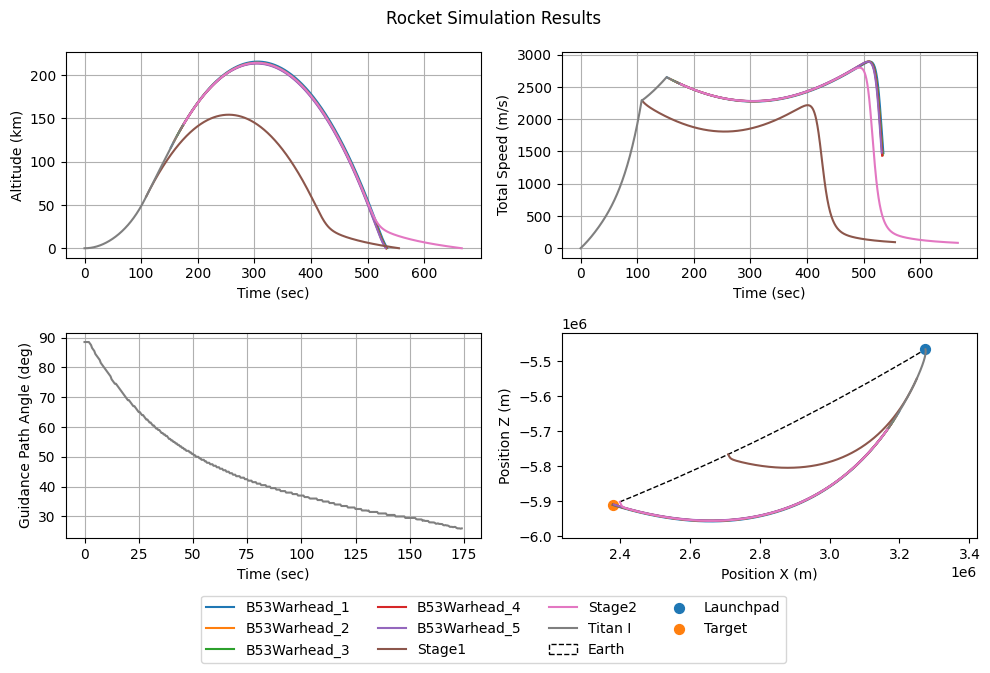

In [37]:
fig, ax = plt.subplots(ncols=2, nrows=2, figsize=(10, 6))
ax = ax.ravel()

sns.lineplot(data=df, x="time", y="altitude_km", hue="name", ax=ax[0])
sns.lineplot(data=df, x="time", y="speed", hue="name", ax=ax[1])
sns.lineplot(data=df, x="time", y="gamma_deg", hue="name", ax=ax[2])
sns.lineplot(data=df, x="posx", y="posz", hue="name", ax=ax[3], sort=False, errorbar=None)

ax[0].set_xlabel("Time (sec)")
ax[0].set_ylabel("Altitude (km)")

ax[1].set_xlabel("Time (sec)")
ax[1].set_ylabel("Total Speed (m/s)")

ax[2].set_xlabel("Time (sec)")
ax[2].set_ylabel("Guidance Path Angle (deg)")

plot_2D_planet_with_points(earth, points = [launchpad, target], ax=ax[3], display="arc")
ax[3].set_xlabel("Position X (m)")
ax[3].set_ylabel("Position Z (m)")
ax[3].set_aspect("equal", adjustable="datalim")

for a in ax:
    a.grid()
    a.legend()
    handles, labels = a.get_legend_handles_labels()
    a.legend().remove()

fig.suptitle("Rocket Simulation Results")
fig.legend(handles, labels, loc="lower center", ncol=4, bbox_to_anchor=(0.5, -0.12))
fig.tight_layout(pad=1.2)

In [12]:

u, v = np.mgrid[0:2*np.pi:60j, 0:np.pi:30j]
R = earth.radius

fig = go.Figure()

# Planet sphere
fig.add_trace(go.Surface(
    x=R * np.cos(u) * np.sin(v),
    y=R * np.sin(u) * np.sin(v),
    z=R * np.cos(v),
    colorscale="Blues", showscale=False, opacity=0.6,
    name="Earth", hoverinfo="skip",
))

# One trace per object, coloured like seaborn hue="name"
colors = [
    "#636EFA", "#EF553B", "#00CC96", "#AB63FA", "#FFA15A",
    "#19D3F3", "#FF6692", "#B6E880", "#FF97FF", "#FECB52",
]
for i, (name, group) in enumerate(df.groupby("name", sort=False)):
    pos = np.stack(group.sort_values("time")["position"].values)
    fig.add_trace(go.Scatter3d(
        x=pos[:, 0], y=pos[:, 1], z=pos[:, 2],
        mode="lines",
        line=dict(width=4, color=colors[i % len(colors)]),
        name=name,
    ))

fig.update_layout(
    scene=dict(aspectmode="data"),
    legend=dict(x=0, y=1),
    margin=dict(l=0, r=0, t=30, b=0),
)
fig.show()
